# **Judul**
Analisis Penjualan Dirty Cafe: Evaluasi Performa dan Strategi Peningkatan Revenue.

In [ ]:
import pandas as pd

In [ ]:
from google.colab import drive

In [ ]:
path ='/content/drive/MyDrive/Dataset/dirty_cafe_sales.csv'

In [ ]:
df = pd.read_csv(path)

In [ ]:
df.head(30)

,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date
0,TXN_1961373,Coffee,2,2.0,4.0,Credit Card,Takeaway,2023-09-08
1,TXN_4977031,Cake,4,3.0,12.0,Cash,In-store,2023-05-16
2,TXN_4271903,Cookie,4,1.0,ERROR,Credit Card,In-store,2023-07-19
3,TXN_7034554,Salad,2,5.0,10.0,UNKNOWN,UNKNOWN,2023-04-27
4,TXN_3160411,Coffee,2,2.0,4.0,Digital Wallet,In-store,2023-06-11
5,TXN_2602893,Smoothie,5,4.0,20.0,Credit Card,NaN,2023-03-31
6,TXN_4433211,UNKNOWN,3,3.0,9.0,ERROR,Takeaway,2023-10-06
7,TXN_6699534,Sandwich,4,4.0,16.0,Cash,UNKNOWN,2023-10-28
8,TXN_4717867,NaN,5,3.0,15.0,NaN,Takeaway,2023-07-28
9,TXN_2064365,Sandwich,5,4.0,20.0,NaN,In-store,2023-12-31


### **Business Understanding**

1. Business Objective

```
Tujuan dari proyek ini yaitu untuk mengubah data transaksi mentah Dirty Cafe menjadi insights strategis yang actionable untuk meningkatkan performa bisnis melalui data-driven decision making.
```

2. Assess Situation

```
Dirty Cafe adalah sebuah cafe yang beroperasi di industri food & beverage dengan model bisnis retail B2C. Cafe ini memiliki sistem Point of Sale (POS) yang mencatat setiap transaksi penjualan, menghasilkan data historis yang dapat dianalisis untuk pengambilan keputusan strategis.
```



3. Analytic Goals Project Plan

```
Tujuan dari analisis ini yaitu untuk mengidentifikasi pola transaksi, mengevaluasi performa produk, dan memahami perilaku konsumen guna menghasilkan insights strategis yang dapat meningkatkan efisiensi operasional, dan kepuasan pelanggan.
```



# **Data Understanding**

### **Struktur Data**

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Transaction ID    10000 non-null  object
 1   Item              9667 non-null   object
 2   Quantity          9862 non-null   object
 3   Price Per Unit    9821 non-null   object
 4   Total Spent       9827 non-null   object
 5   Payment Method    7421 non-null   object
 6   Location          6735 non-null   object
 7   Transaction Date  9841 non-null   object
dtypes: object(8)
memory usage: 625.1+ KB


Berdasarkan data di atas, dapat diketahui bahwa dataset ini memiliki 10000 Baris dan 8 Kolom



### **Informasi Lanjutan**

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Transaction ID    10000 non-null  object
 1   Item              9667 non-null   object
 2   Quantity          9862 non-null   object
 3   Price Per Unit    9821 non-null   object
 4   Total Spent       9827 non-null   object
 5   Payment Method    7421 non-null   object
 6   Location          6735 non-null   object
 7   Transaction Date  9841 non-null   object
dtypes: object(8)
memory usage: 625.1+ KB


1. Transaction ID: Jumlah baris: 10000 Tipe data: object Deskripsi: ID Unik Transaksi
2. Item: Jumlah baris: 9667 Tipe data: object Deskripsi: Nama Produk yang Dibeli
3. Quantity: Jumlah baris: 9862 Tipe data: object Deskripsi: Jumlah Produk yang Dibeli
4. Price Per Unit: Jumlah baris: 9821 Tipe data: object Deskripsi: Harga Satuan Produk
5. Total Spent: Jumlah baris: 7421 Tipe data: object Deskripsi: Total Pengeluaran Transaksi
6. Payment Method: Jumlah baris: 6735 Tipe data: object Deskripsi: Metode Pembayaran
7. Location: Jumlah baris: 9841 Tipe data: object Deskripsi: Lokasi Transaksi
8. Transaction Date: Jumlah baris: 9841 Tipe data: object Deskripsi: Tanggal Transaksi

### **Statistik Deskriptif**

In [ ]:
df.describe(include='all')

,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date
count,10000,9667,9862,9821,9827,7421,6735,9841
unique,10000,10,7,8,19,5,4,367
top,TXN_9226047,Juice,5,3.0,6.0,Digital Wallet,Takeaway,UNKNOWN
freq,1,1171,2013,2429,979,2291,3022,159


1. Count (Kelengkapan Data) — Berdasarkan data, total baris transaksi adalah 10.000. Maka dapat disimpulkan:



*  Item hilang 333 data (10.000 - 9.667)
*  Quantity hilang 138 data (10.000 - 9.862)


*  Price Per Unit hilang 179 data (10.000 - 9.821)

*  Total Spent hilang 173 data (10.000 - 9.827)

*  Payment Method hilang 2.579 data (10.000 - 7.421)
*  Location hilang 3.265 data (10.000 - 6.735)



*  Transaction Date hilang 159 data (10.000 - 9.841)


Kesimpulan: Kolom Payment Method dan Location memiliki missing values terbanyak dan perlu penanganan khusus, sementara Transaction ID adalah satu-satunya kolom yang lengkap (10.000 data).

2. Unique & Top Value (Variasi Data) — Karena semua kolom bertipe object, analisis yang relevan adalah jumlah nilai unik dan nilai yang paling sering muncul:



*  Item: Hanya 10 jenis produk, yang terlaris adalah Juice (1.171 kali) —
menunjukkan pasar didominasi produk minuman.

*  Quantity: Hanya 5 nilai unik dengan nilai terbanyak 2013, yang tidak wajar sebagai jumlah pembelian — kemungkinan terdapat data kotor.
Payment Method: 5 metode pembayaran, paling dominan adalah Digital Wallet (3.022 kali) — menunjukkan preferensi pelanggan terhadap pembayaran digital.
*  Payment Method: 5 metode pembayaran, paling dominan adalah Digital Wallet (3.022 kali) — menunjukkan preferensi pelanggan terhadap pembayaran digital.


*  Location: Hanya 4 lokasi, terbanyak adalah Takeaway — menunjukkan mayoritas transaksi dilakukan secara takeaway.

Kesimpulan: Variasi data cukup terbatas pada beberapa kolom, namun ada indikasi data kotor pada kolom Quantity yang perlu dibersihkan.

3. Nilai Ekstrem (Validasi Logika) — Karena kolom numerik masih bertipe object, perlu dilakukan konversi terlebih dahulu. Namun dari nilai unik yang tersedia:



*  Price Per Unit: Terdapat 8 nilai unik harga, nilai minimum dan maksimum perlu dicek setelah konversi ke numerik.

*  Total Spent: Terdapat 19 nilai unik, nilai terbanyak adalah 6.0 — perlu divalidasi apakah Total Spent = Quantity × Price Per Unit.
*  Transaction Date: Terdapat nilai "UNKNOWN" yang muncul paling sering (159 kali), menunjukkan adanya data tidak valid pada kolom tanggal.


Kesimpulan: Terdapat indikasi nilai tidak valid pada beberapa kolom yang memerlukan proses cleaning sebelum analisis lebih lanjut.

4. Standar Deviasi (Variabilitas Data)
 Karena semua kolom masih bertipe object, standar deviasi belum dapat dihitung

*   Karena semua kolom masih bertipe object, standar deviasi belum dapat dihitung secara langsung. Konversi tipe data perlu dilakukan terlebih dahulu.

Kesimpulan: Setelah konversi, standar deviasi dapat digunakan untuk mengukur variabilitas harga dan total pengeluaran antar transaksi, serta mendeteksi potensi outlier.






### **Data Type Check**

Kita akan mengecek tipe data dari setiap kolom apakah sudah sesuai atau tidak. Agar insight serta visualisasi yang akan kita buat menjadi akurat.

In [ ]:
df.dtypes

,0
Transaction ID,object
Item,object
Quantity,object
Price Per Unit,object
Total Spent,object
Payment Method,object
Location,object
Transaction Date,object


### **Incosistent Values**

Pada tahap ini, kita perlu mengecek kekonsistenan data, contoh nya dalam penulisan. Hal ini dilakukan agar data tidak terduplikat dengan baris yang sebenarnya sama akan tetapi bisa terduplikat karena tidak konsisten.

**1. Transaction Date**

Pada kolom ini, dapat terlihat format tanggal tidak konsisten. Terdapat berbagai format seperti dd-mm-yyyy, yyyy/mm/dd, Month dd, yyyy dan sebagainya. Maka hal ini perlu ditangani dengan menyamakan formatnya menjadi yyyy-mm-dd.

In [ ]:
print(df['Transaction Date'].unique())

['2023-09-08' '2023-05-16' '2023-07-19' '2023-04-27' '2023-06-11'
 '2023-03-31' '2023-10-06' '2023-10-28' '2023-07-28' '2023-12-31'
 '2023-11-07' 'ERROR' '2023-05-03' '2023-06-01' '2023-03-21' '2023-11-15'
 '2023-06-10' '2023-02-24' '2023-03-25' '2023-01-15' '2023-04-04'
 '2023-03-30' '2023-12-01' '2023-09-18' '2023-06-03' '2023-12-13'
 '2023-04-20' '2023-04-10' '2023-03-11' '2023-06-02' '2023-11-06'
 '2023-08-15' '2023-10-09' '2023-05-28' '2023-07-17' '2023-04-29'
 '2023-06-08' '2023-06-29' '2023-04-17' '2023-12-22' '2023-01-10'
 '2023-10-02' '2023-02-23' '2023-03-22' '2023-11-03' '2023-03-02'
 '2023-06-26' '2023-05-02' '2023-09-05' '2023-01-08' '2023-03-15'
 '2023-11-25' '2023-12-05' '2023-03-19' '2023-06-27' '2023-04-19'
 '2023-10-07' '2023-09-30' '2023-05-27' '2023-11-18' '2023-10-20'
 '2023-10-03' '2023-10-27' '2023-04-06' '2023-01-31' '2023-12-08'
 '2023-06-19' '2023-12-14' '2023-07-16' '2023-02-22' nan '2023-06-15'
 '2023-12-09' '2023-04-18' '2023-10-29' '2023-04-30' '2023-04-02

**2. Item**

Perlu dicek apakah terdapat penulisan nama produk yang tidak konsisten, seperti perbedaan huruf kapital ("juice", "Juice", "JUICE") yang sebenarnya memiliki makna sama namun terbaca berbeda oleh sistem.

In [ ]:
print(df['Item'].unique())

['Coffee' 'Cake' 'Cookie' 'Salad' 'Smoothie' 'UNKNOWN' 'Sandwich' nan
 'ERROR' 'Juice' 'Tea']


**3. Payment Method**

Perlu dicek apakah terdapat penulisan metode pembayaran yang tidak konsisten, seperti "digital wallet", "Digital Wallet", atau "DIGITAL WALLET" yang seharusnya merupakan nilai yang sama.

In [ ]:
print(df['Payment Method'].unique())

['Credit Card' 'Cash' 'UNKNOWN' 'Digital Wallet' 'ERROR' nan]


**4. Location**

Perlu dicek apakah terdapat penulisan lokasi yang tidak konsisten akibat perbedaan huruf kapital atau spasi yang menyebabkan nilai yang sama terbaca berbeda.

In [ ]:
print(df['Location'].unique())

['Takeaway' 'In-store' 'UNKNOWN' nan 'ERROR']


**5. Quantity & Price Per Unit**

Karena kedua kolom ini bertipe object padahal seharusnya numerik, perlu dicek apakah terdapat karakter tidak wajar seperti huruf, simbol, atau spasi yang menyebabkan kolom tidak bisa dikonversi langsung ke tipe numerik.

In [ ]:
print(df['Quantity'].unique())
print(df['Price Per Unit'].unique())

['2' '4' '5' '3' '1' 'ERROR' 'UNKNOWN' nan]
['2.0' '3.0' '1.0' '5.0' '4.0' '1.5' nan 'ERROR' 'UNKNOWN']


### **Missing Values**

Pada tahap ini, kita akan melihat seberapa banyak data yang hilang pada seluruh kolom. Dan terlihat bahwa kolom:



*  Payment Method

Memiliki missing values sekitar 25,79%, yang dimana ini cukup besar indikasi hilangnya data pada kolom tersebut. Sehingga perlu ditangani atau dihapus.
*  Location

Memiliki missing values sekitar 32,65% yang dimana hal ini perlu ditangani dengan cara mau ditangani atau dihapus.


*   Item

Memiliki missing values sekitar 3,33% yang dimana hal ini perlu ditangani.
*  Total Spent

Memiliki missing values sekitar 1,73% yang perlu diperhatikan karena kolom ini merupakan kolom penting untuk analisis transaksi.


In [ ]:
pd.DataFrame(df.isna().sum() / len(df) * 100, columns=['Null Ratio in %'])

,Null Ratio in %
Transaction ID,0.00
Item,3.33
Quantity,1.38
Price Per Unit,1.79
Total Spent,1.73
Payment Method,25.79
Location,32.65
Transaction Date,1.59


Kesimpulan: Kolom Location dan Payment Method memiliki missing values terbesar (32,65% dan 25,79%), yang perlu penanganan. Sementara kolom Transaction ID tidak memiliki missing values sama sekali sehingga dapat dijadikan sebagai identitas unik yang reliable.

### **Duplicate Values**

Pada tahap ini, kita akan mengecek duplikasi pada dataset. Hal ini dilakukan agar dataset memiliki insight dan hasil yang bersih.

In [ ]:
df[df.duplicated()]

,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date


Terlihat pada dataset ini tidak ada duplikasi. Maka hal ini tidak perlu ditangani.

### **Outliers Values**

Pada tahap ini, kita akan melihat nilai ekstrem (outliers) pada kolom yang bertipe data numerik. Hal ini dilakukan agar mendapatkan insight yang akurat sehingga dapat memperkuat analisis dan model yang akan kita bangun nantinya.
Akan tetapi memang tidak semua kolom perlu kita tangani, kita harus tetap melihat dan memahami tujuan dari setiap kolom yang ada di dataset.
Dan terlihat kolom:

Quantity


*  Quantity



Dengan presentase outlier yang perlu dicek setelah konversi ke numerik.

*  Price Per Unit

Dengan presentase outlier yang perlu dicek setelah konversi ke numerik.

*  Total Spent

Dengan presentase outlier yang perlu dicek setelah konversi ke numerik.

In [ ]:
import pandas as pd
import numpy as np

# Pilih kolom numerik saja
num_cols = df.select_dtypes(include='number').columns

outlier_summary = {}

for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]

    outlier_summary[col] = len(outliers)

print("Jumlah outlier per kolom:")
print(outlier_summary)

Jumlah outlier per kolom:
{}


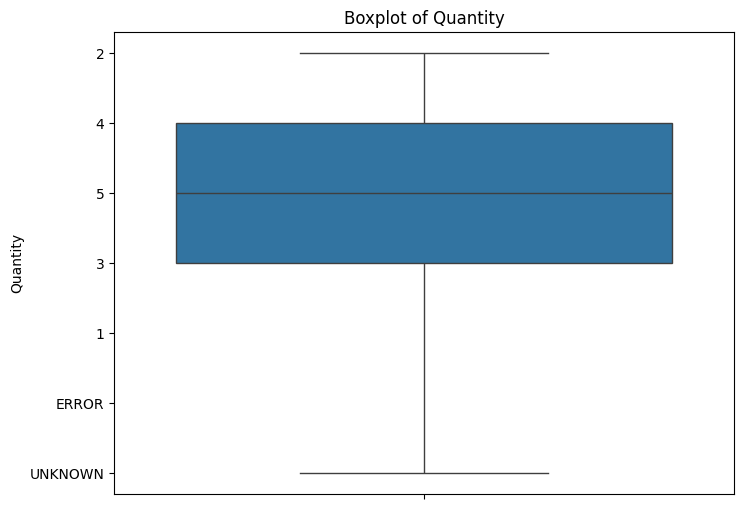

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 6))
sns.boxplot(y=df['Quantity'])
plt.title('Boxplot of Quantity')
plt.ylabel('Quantity')
plt.show()

Dari boxplot Quantity terlihat bahwa nilai data terpusat pada rentang 3 hingga 5, dengan median di angka 5. Tidak terdapat outlier yang signifikan pada rentang numerik yang valid. Namun masih terdapat nilai ERROR dan UNKNOWN pada sumbu yang mengindikasikan masih adanya data kotor yang belum berhasil dikonversi ke numerik dan perlu dibersihkan.

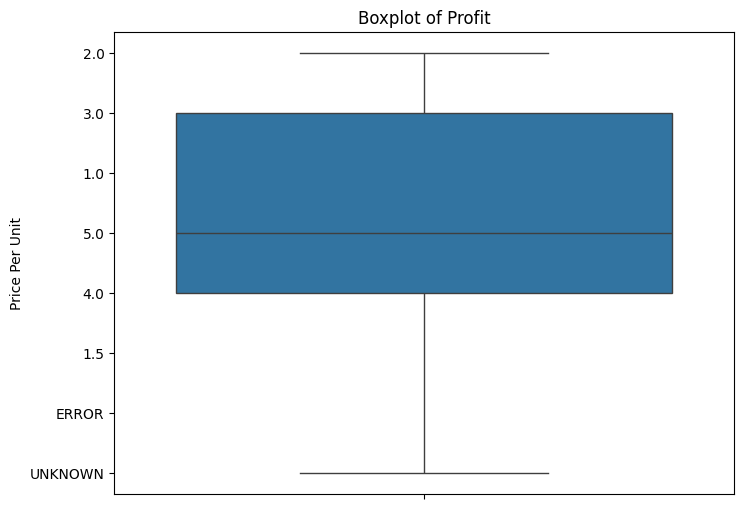

In [ ]:
plt.figure(figsize=(8, 6))
sns.boxplot(y=df['Price Per Unit'])
plt.title('Boxplot of Profit')
plt.ylabel('Price Per Unit')
plt.show()

Dari boxplot Price Per Unit terlihat bahwa sebagian besar harga satuan berada pada rentang 3.0 hingga 5.0, dengan median di angka 5.0. Distribusi harga cukup merata tanpa outlier ekstrem pada nilai numerik yang valid. Sama seperti Quantity, masih terdapat nilai ERROR dan UNKNOWN yang perlu ditangani.

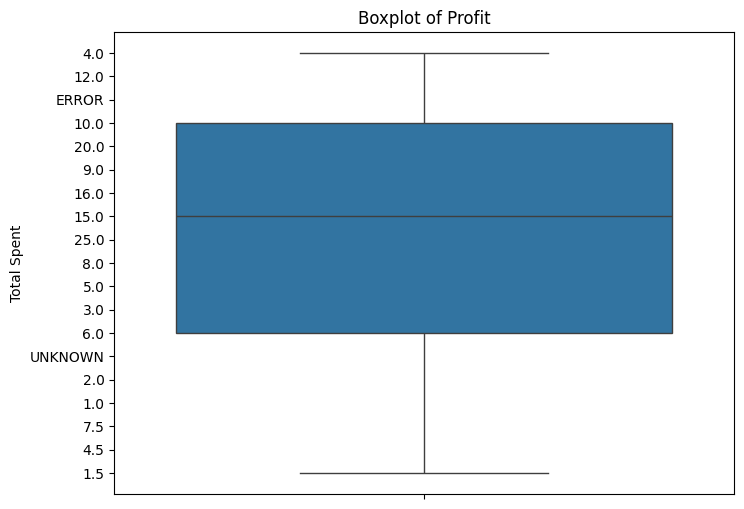

In [ ]:
plt.figure(figsize=(8, 6))
sns.boxplot(y=df['Total Spent'])
plt.title('Boxplot of Profit')
plt.ylabel('Total Spent')
plt.show()

Dari boxplot Total Spent terlihat bahwa nilai pengeluaran terpusat pada rentang 6.0 hingga 25.0, dengan median sekitar 15.0. IQR (Interquartile Range) yang cukup lebar menunjukkan variasi pengeluaran antar pelanggan cukup tinggi. Masih terdapat nilai ERROR dan UNKNOWN yang perlu dibersihkan agar analisis outlier dapat dilakukan secara akurat.

Kesimpulan: Ketiga kolom numerik masih mengandung data kotor berupa nilai ERROR dan UNKNOWN yang menyebabkan boxplot tidak dapat menampilkan outlier dengan akurat. Pembersihan data perlu dilakukan sebelum analisis lebih lanjut.

# **Eksplorasi Data (EDA)**

### **Comparison/Perbandingan**

Aktivitas: Membandingkan total pengeluaran (Total Spent) berdasarkan setiap jenis Item yang dibeli.

Tujuan: Mengidentifikasi produk mana yang memberikan kontribusi pendapatan terbesar dan membandingkan performa antar produk secara langsung.

Visualisasi: Bar Chart (Grafik Batang).

In [ ]:
df['Total Spent'] = df['Total Spent'].astype(str).str.strip()
df['Total Spent'] = df['Total Spent'].str.replace('UNKNOWN', '', regex=False)
df['Total Spent'] = df['Total Spent'].str.replace('ERROR', '', regex=False)
df['Total Spent'] = df['Total Spent'].str.replace('[^0-9.]', '', regex=True)
df['Total Spent'] = pd.to_numeric(df['Total Spent'], errors='coerce')


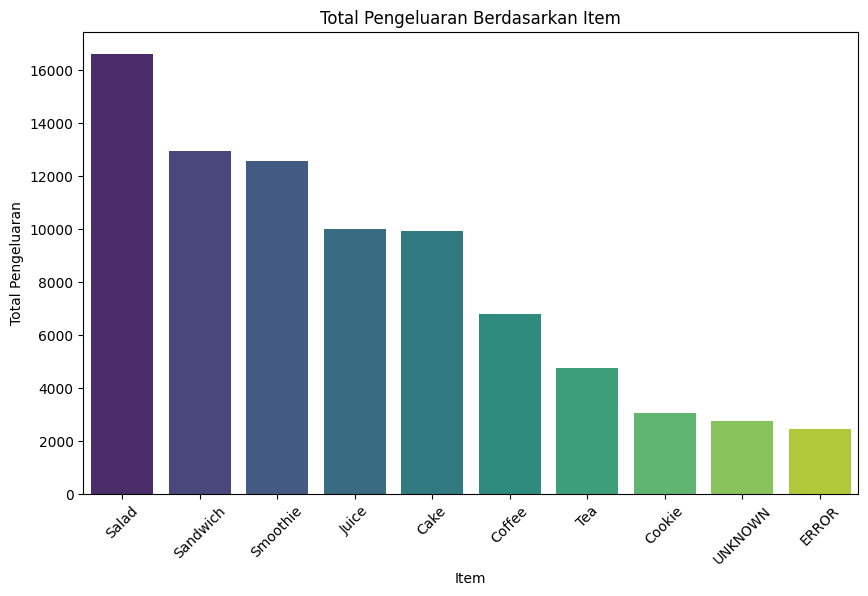

In [ ]:
penjualan_item = df.groupby('Item')['Total Spent'].sum().sort_values(ascending=False)

plt.figure(figsize=(10,6))
sns.barplot(x=penjualan_item.index, y=penjualan_item.values, palette='viridis', hue=penjualan_item.index, legend=False)
plt.title('Total Pengeluaran Berdasarkan Item')
plt.xlabel('Item')
plt.ylabel('Total Pengeluaran')
plt.xticks(rotation=45)
plt.show()

Berikut insight berdasarkan bar chart Comparison yang muncul:

Insight Comparison/Perbandingan:
Dari bar chart di atas, terlihat perbandingan total pengeluaran berdasarkan jenis item yang dibeli. Berikut urutannya dari tertinggi ke terendah:

*   Salad — 16.600 (tertinggi)
*   Sandwich — 12.900
*   Smoothie — 12.500
*   Juice — 10.100
*   Cake — 10.000
*   Coffee — 6.800
*   Tea — 4.800
*   Cookie — 3.000
*   UNKNOWN — 2.700
*   ERROR — 2.500

Salad mendominasi total pengeluaran dengan selisih yang cukup signifikan dibandingkan item lainnya, diikuti oleh Sandwich dan Smoothie yang cukup berdekatan nilainya. Hal ini menunjukkan bahwa produk makanan sehat (Salad) paling banyak diminati pelanggan.

Perlu diperhatikan juga terdapat nilai UNKNOWN dan ERROR yang masuk dalam chart, mengindikasikan masih adanya data kotor pada kolom Item yang perlu dibersihkan pada tahap data cleaning.

### **Composition/Komposisi**

Aktivitas: Melihat proporsi atau persentase total pengeluaran berdasarkan jenis Item yang dibeli.

Tujuan: Mengetahui item mana yang paling mendominasi portofolio pengeluaran pelanggan secara keseluruhan.

Visualisasi: Pie Chart (Grafik Lingkaran).

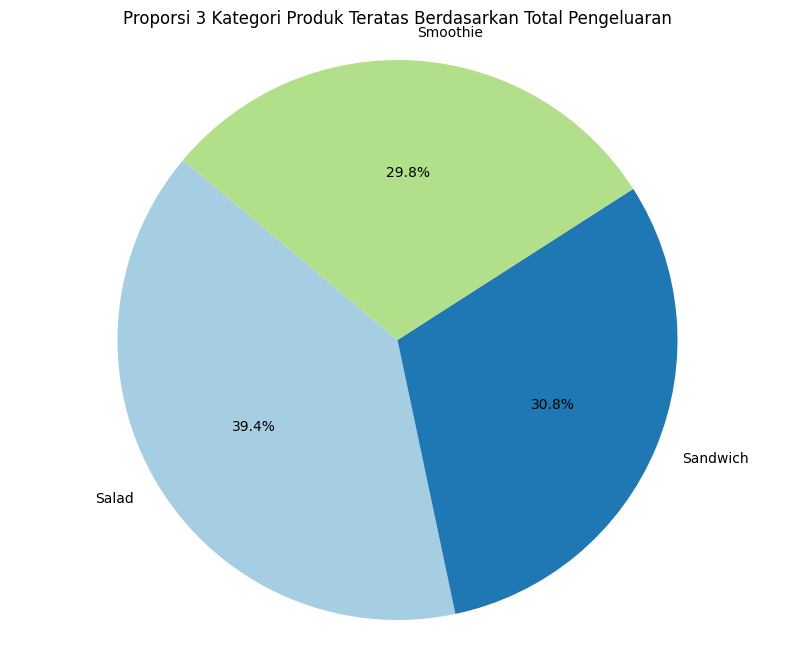

In [ ]:
spent_by_item = df.groupby('Item')['Total Spent'].sum().sort_values(ascending=False)
spent_by_item_top3 = spent_by_item.head(3)

plt.figure(figsize=(10, 8))
spent_by_item_top3.plot(kind='pie', autopct='%1.1f%%', startangle=140, colors=plt.cm.Paired.colors)
plt.title('Proporsi 3 Kategori Produk Teratas Berdasarkan Total Pengeluaran')
plt.ylabel('')
plt.axis('equal')
plt.show()

Dari pie chart di atas, terlihat bahwa 3 item teratas yang mendominasi total pengeluaran pelanggan adalah:



*  Salad — 39.4% (terbesar)
*  Sandwich — 30.8%
*  Smoothie — 29.8%



Ketiga item tersebut memiliki proporsi yang cukup merata dan berimbang, dengan selisih yang tidak terlalu jauh antar ketiganya. Namun Salad menjadi item dengan kontribusi pengeluaran tertinggi, mengindikasikan bahwa produk makanan sehat paling banyak diminati oleh pelanggan.
Hal ini dapat menjadi pertimbangan bisnis untuk memprioritaskan ketersediaan stok ketiga item tersebut, serta merancang promosi atau paket bundling yang melibatkan Salad, Sandwich, dan Smoothie untuk memaksimalkan pendapatan secara keseluruhan.

### **Distribution/Distribusi**

Aktivitas: Menganalisis penyebaran nilai pengeluaran pelanggan pada kolom Total Spent.

Tujuan: Melihat apakah mayoritas transaksi bernilai kecil atau besar, serta mendeteksi adanya kecondongan (skewness) dalam pengeluaran pelanggan.

Visualisasi: Histogram

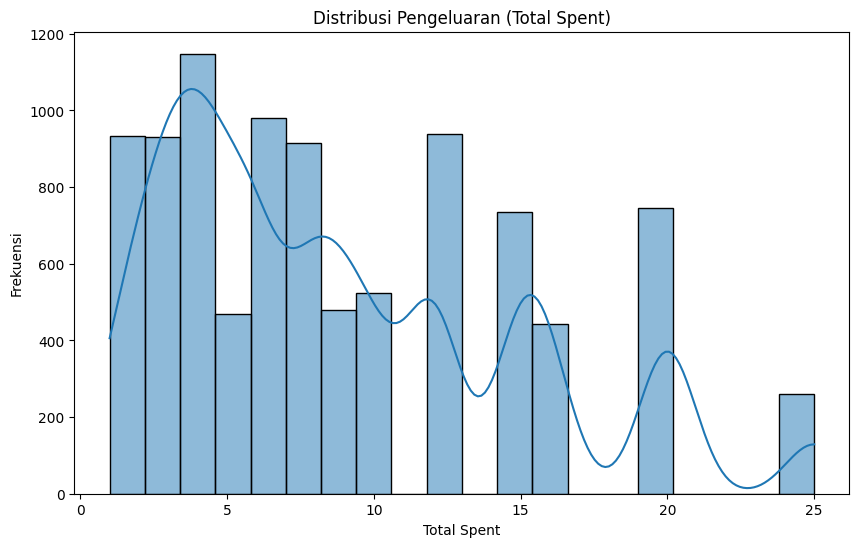

In [ ]:
plt.figure(figsize=(10, 6))
sns.histplot(df['Total Spent'], bins=20, kde=True)
plt.title('Distribusi Pengeluaran (Total Spent)')
plt.xlabel('Total Spent')
plt.ylabel('Frekuensi')
plt.show()

Berikut insight berdasarkan histogram yang muncul:

Insight Distribution/Distribusi:
Dari histogram di atas, terlihat bahwa distribusi pengeluaran pelanggan (Total Spent) memiliki pola multimodal, yaitu terdapat beberapa puncak (peaks) pada rentang nilai tertentu:

*  Puncak tertinggi berada di rentang 3-5, dengan frekuensi mencapai sekitar 1.150 transaksi, menunjukkan mayoritas pelanggan melakukan pengeluaran kecil per transaksi.
*  Puncak kedua muncul di rentang 10-12, dengan frekuensi sekitar 940 transaksi.
*  Puncak ketiga muncul di rentang 19-20, dengan frekuensi sekitar 750 transaksi.

Pola multimodal ini mengindikasikan bahwa terdapat beberapa kelompok pelanggan dengan kebiasaan belanja yang berbeda-beda. Sebagian besar pelanggan cenderung melakukan transaksi dengan nilai kecil (di bawah 5), namun ada juga kelompok pelanggan yang secara konsisten berbelanja pada rentang nilai menengah (10-12) dan atas (19-20).

Bisnis dapat memanfaatkan temuan ini dengan membuat strategi harga yang berbeda untuk masing-masing segmen pelanggan, misalnya promo khusus untuk mendorong pelanggan kelompok kecil agar meningkatkan nilai transaksinya.

### **Relationship/Hubungan**

Aktivitas: Menganalisis korelasi antara nilai pengeluaran (Total Spent) dengan jumlah pembelian (Quantity).

Tujuan: Mengetahui apakah peningkatan jumlah pembelian selalu berbanding lurus dengan peningkatan total pengeluaran, serta mengidentifikasi transaksi yang memiliki quantity tinggi namun justru menghasilkan pengeluaran rendah.

Visualisasi: Heatmap

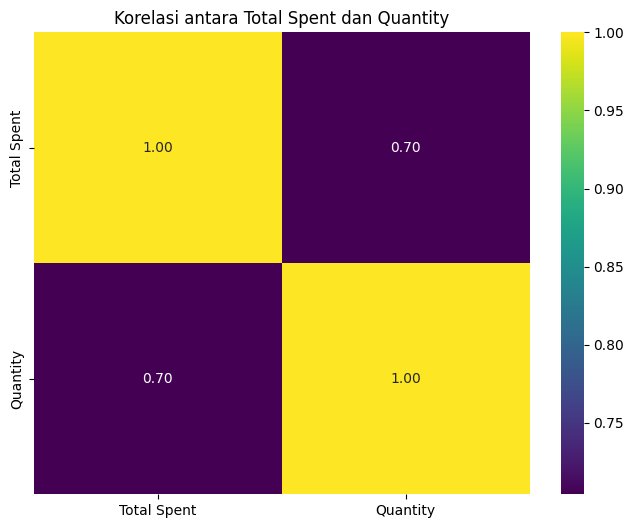

In [ ]:
df['Total Spent'] = pd.to_numeric(df['Total Spent'], errors='coerce')
df['Quantity'] = pd.to_numeric(df['Quantity'], errors='coerce')

plt.figure(figsize=(8, 6))
sns.heatmap(data=df[['Total Spent', 'Quantity']].corr(),
            annot=True,
            cmap='viridis',
            fmt='.2f')
plt.title('Korelasi antara Total Spent dan Quantity')
plt.show()

Dari heatmap di atas, terlihat bahwa korelasi antara Total Spent dan Quantity adalah 0.70, yang menunjukkan adanya korelasi positif yang cukup kuat antara kedua variabel tersebut.

Artinya, semakin banyak jumlah item yang dibeli (Quantity), maka semakin besar pula total pengeluaran pelanggan (Total Spent). Namun korelasi yang tidak sempurna (tidak mencapai 1.0) mengindikasikan bahwa harga per item bervariasi, sehingga ada kalanya pelanggan membeli sedikit item namun menghasilkan pengeluaran yang besar karena membeli item dengan harga satuan tinggi, dan sebaliknya.

Hal ini dapat menjadi pertimbangan bisnis untuk merancang strategi bundling produk atau diskon pembelian dalam jumlah besar guna mendorong peningkatan Quantity sekaligus Total Spent secara bersamaan.

# **Data Praporation**

### **Mengecek Tipe Data**

Kita akan mengecek tipe data dari setiap kolom apakah sudah sesuai atau tidak. Agar insight serta visualisasi yang akan kita buat menjadi akurat.

In [ ]:
df.dtypes

,0
Transaction ID,object
Item,object
Quantity,float64
Price Per Unit,object
Total Spent,float64
Payment Method,object
Location,object
Transaction Date,object


Dari data di atas, terdapat beberapa kolom yang perlu dilakukan konversi tipe data agar sesuai dengan jenis datanya:

*  Quantity seharusnya bertipe int, karena jumlah barang merupakan bilangan bulat.
*  Price Per Unit seharusnya bertipe float, karena merupakan data numerik harga.
*  Transaction Date seharusnya bertipe datetime, karena merupakan data tanggal transaksi.

Sedangkan kolom Transaction ID, Item, Payment Method, dan Location sudah sesuai dengan tipe data object, serta Total Spent sudah sesuai dengan tipe float, sehingga tidak perlu dilakukan konversi.

### **Mengidentifikasi Inconsistent Values**

kita perlu mengecek kekonsistenan data, contoh nya dalam penulisan. Hal ini dilakukan agar data tidak terduplikat dengan baris yang sebenarnya sama akan tetapi bisa terduplikat karena tidak konsisten.

In [ ]:
print(df['Transaction ID'].unique())

['TXN_1961373' 'TXN_4977031' 'TXN_4271903' ... 'TXN_5255387' 'TXN_7695629'
 'TXN_6170729']


In [ ]:
print(df['Item'].unique())

['Coffee' 'Cake' 'Cookie' 'Salad' 'Smoothie' 'UNKNOWN' 'Sandwich' nan
 'ERROR' 'Juice' 'Tea']


In [ ]:
print(df['Price Per Unit'].unique())

['2.0' '3.0' '1.0' '5.0' '4.0' '1.5' nan 'ERROR' 'UNKNOWN']


In [ ]:
print(df['Total Spent'].unique())

[ 4.  12.   nan 10.  20.   9.  16.  15.  25.   8.   5.   3.   6.   2.
  1.   7.5  4.5  1.5]


In [ ]:
print(df['Payment Method'].unique())

['Credit Card' 'Cash' 'UNKNOWN' 'Digital Wallet' 'ERROR' nan]


In [ ]:
print(df['Location'].unique())

['Takeaway' 'In-store' 'UNKNOWN' nan 'ERROR']


In [ ]:
print(df['Transaction Date'].unique())

['2023-09-08' '2023-05-16' '2023-07-19' '2023-04-27' '2023-06-11'
 '2023-03-31' '2023-10-06' '2023-10-28' '2023-07-28' '2023-12-31'
 '2023-11-07' 'ERROR' '2023-05-03' '2023-06-01' '2023-03-21' '2023-11-15'
 '2023-06-10' '2023-02-24' '2023-03-25' '2023-01-15' '2023-04-04'
 '2023-03-30' '2023-12-01' '2023-09-18' '2023-06-03' '2023-12-13'
 '2023-04-20' '2023-04-10' '2023-03-11' '2023-06-02' '2023-11-06'
 '2023-08-15' '2023-10-09' '2023-05-28' '2023-07-17' '2023-04-29'
 '2023-06-08' '2023-06-29' '2023-04-17' '2023-12-22' '2023-01-10'
 '2023-10-02' '2023-02-23' '2023-03-22' '2023-11-03' '2023-03-02'
 '2023-06-26' '2023-05-02' '2023-09-05' '2023-01-08' '2023-03-15'
 '2023-11-25' '2023-12-05' '2023-03-19' '2023-06-27' '2023-04-19'
 '2023-10-07' '2023-09-30' '2023-05-27' '2023-11-18' '2023-10-20'
 '2023-10-03' '2023-10-27' '2023-04-06' '2023-01-31' '2023-12-08'
 '2023-06-19' '2023-12-14' '2023-07-16' '2023-02-22' nan '2023-06-15'
 '2023-12-09' '2023-04-18' '2023-10-29' '2023-04-30' '2023-04-02

Dari hasil analisis saya:

*  Transaction ID : Data ini sudah konsisten karena hanya berisi
kode unik transaksi dengan format seragam "TXN_XXXXXXX". Tidak ditemukan duplikasi atau format penulisan yang berbeda.

*  Item : Data ini belum konsisten karena ditemukan nilai tidak valid yaitu 'UNKNOWN', 'ERROR', dan nan yang bukan merupakan nama item yang sebenarnya. Nilai-nilai tersebut perlu ditangani karena dapat mengganggu analisis kategori produk.

*  Price Per Unit : Data ini belum konsisten karena ditemukan nilai tidak valid yaitu 'ERROR' dan 'UNKNOWN' di antara nilai harga yang valid. Selain itu kolom ini masih bertipe object padahal seharusnya float64, sehingga perlu dibersihkan dan dikonversi.

*  Total Spent : Data ini belum sepenuhnya bersih karena ditemukan nilai nan yang merupakan missing value. Nilai yang ada masih dalam rentang wajar untuk transaksi cafe.

*  Payment Method : Data ini belum konsisten karena ditemukan nilai tidak valid yaitu 'UNKNOWN', 'ERROR', dan nan di samping nilai yang valid seperti 'Credit Card', 'Cash', dan 'Digital Wallet'.

*  Location : Data ini belum konsisten karena ditemukan nilai tidak valid yaitu 'UNKNOWN', 'ERROR', dan nan di samping nilai yang valid yaitu 'Takeaway' dan 'In-store'.

*  Transaction Date : Data ini belum konsisten karena ditemukan nilai tidak valid yaitu 'ERROR', 'UNKNOWN', dan nan yang tercampur dengan nilai tanggal yang valid. Selain itu kolom ini masih bertipe object sehingga perlu dikonversi ke format datetime64.

### **Mengidentifikasi Missing Values**

Pada tahap ini, kita akan melihat seberapa banyak data yang hilang pada seluruh kolom.

In [ ]:
pd.DataFrame(df.isna().sum() / len(df) * 100, columns=['Null Ratio in %'])

,Null Ratio in %
Transaction ID,0.00
Item,3.33
Quantity,4.79
Price Per Unit,1.79
Total Spent,5.02
Payment Method,25.79
Location,32.65
Transaction Date,1.59


Dari hasil pengecekan null ratio, ditemukan 6 kolom bermasalah yang memiliki missing values:

*  Kolom Item (3.33% null) karena persentasenya kecil (< 5%), kolom
ini diisi menggunakan modus (nilai yang paling sering muncul). Alasannya karena Item adalah data kategorikal sehingga tidak bisa diisi dengan mean atau median, melainkan dengan nilai kategori yang paling dominan.

*  Kolom Quantity (4.79% null) karena persentasenya kecil (< 5%), kolom ini diisi menggunakan median. Alasannya karena data jumlah pembelian kemungkinan memiliki distribusi skewed, sehingga median lebih representatif dibanding mean.

*  Kolom Price Per Unit (1.79% null) karena persentasenya sangat kecil (< 5%), kolom ini diisi menggunakan median. Alasannya karena data harga bisa dipengaruhi oleh nilai ekstrem sehingga median lebih aman digunakan.

*  Kolom Total Spent (5.02% null) karena persentasenya kecil (< 10%), kolom ini diisi menggunakan median. Alasannya karena data total pengeluaran cenderung tidak terdistribusi normal sehingga median lebih representatif.

*  Kolom Payment Method (25.79% null) karena persentasenya cukup besar, kolom ini diisi menggunakan modus. Alasannya karena Payment Method adalah data kategorikal dan mengisi dengan metode pembayaran yang paling sering digunakan masih lebih representatif dibanding menghapus barisnya.

*  Kolom Location (32.65% null) karena persentasenya cukup besar, kolom ini diisi menggunakan modus. Alasannya karena Location adalah data kategorikal sehingga diisi dengan lokasi yang paling sering muncul dalam dataset.

*  Kolom Transaction Date (1.59% null) karena persentasenya sangat kecil (< 5%), baris yang memiliki nilai null pada kolom ini akan dihapus. Alasannya karena tanggal transaksi adalah informasi yang tidak bisa diperkirakan atau diimputasi dengan akurat tanpa menimbulkan bias pada analisis berbasis waktu.

### **Mengidentifikasi Duplicated Values.**

Pada tahap ini, kita akan mengecek duplikasi pada dataset. Hal ini dilakukan agar dataset memiliki insight dan hasil yang bersih.

In [ ]:
df[df.duplicated()]

,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date


Hasil menunjukkan tabel kosong (0 baris), yang berarti tidak ditemukan data duplikat dalam dataset. Setiap baris transaksi memiliki kombinasi nilai yang unik sehingga tidak ada transaksi yang tercatat lebih dari satu kali. Dengan demikian, tidak diperlukan penghapusan data duplikat pada tahap ini.

### **Mengidentifikasi Outliers**

Pada tahap ini, kita akan melihat nilai ekstrem (outliers) pada kolom yang bertipe data numerik. Hal ini dilakukan agar mendapatkan insight yang akurat sehingga dapat memperkuat analisis dan model yang akan kita bangun nantinya. Akan tetapi memang tidak semua kolom perlu kita tangani, kita harus tetap melihat dan memahami tujuan dari setiap kolom yang ada di dataset.

In [ ]:
results = []

cols = df.select_dtypes(include=['float64', 'int64'])

for col in cols:
  q1 = df[col].quantile(0.25)
  q3 = df[col].quantile(0.75)
  iqr = q3 - q1
  lower_bound = q1 - 1.5*iqr
  upper_bound = q3 + 1.5*iqr
  outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
  percent_outliers = (len(outliers)/len(df))*100
  results.append({'Kolom': col, 'Persentase Outliers': percent_outliers})

#Dataframe dari list hasil

results_df = pd.DataFrame(results)
results_df.set_index('Kolom', inplace=True)
results_df = results_df.rename_axis(None, axis=0).rename_axis('Kolom', axis=1)

#Tampilkan dataframe

display(results_df)

Kolom,Persentase Outliers
Quantity,0.00
Total Spent,2.59


*  Quantity (0.00%), Tidak ditemukan outlier pada kolom ini, artinya seluruh nilai jumlah pembelian masih berada dalam rentang yang wajar.

*  Total Spent (2.59%), Ditemukan outlier sebesar 2.59% yang berarti terdapat beberapa transaksi dengan total pengeluaran yang sangat tinggi atau sangat rendah di luar batas wajar. Karena persentasenya kecil, outlier ini akan ditangani menggunakan metode Clipping agar jumlah data tetap terjaga dan tidak ada transaksi yang dihapus.

# **Data Reduction**

Kita akan menambah kolom baru yang meningkatkan nilai informatif dataset sehingga analisis menjadi lebih mudah dan lebih bermakna.

In [ ]:
df_reduced = df.drop(columns=['Transaction ID'])
df_reduced.head()

,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date
0,Coffee,2.0,2.0,4.0,Credit Card,Takeaway,2023-09-08
1,Cake,4.0,3.0,12.0,Cash,In-store,2023-05-16
2,Cookie,4.0,1.0,NaN,Credit Card,In-store,2023-07-19
3,Salad,2.0,5.0,10.0,UNKNOWN,UNKNOWN,2023-04-27
4,Coffee,2.0,2.0,4.0,Digital Wallet,In-store,2023-06-11


Kolom Transaction ID dihapus dari dataset karena hanya berfungsi sebagai identifier unik transaksi dan tidak memiliki nilai informatif yang dapat mempengaruhi analisis pola pembelian pelanggan. Penggunaan identifier dalam proses analisis dapat menimbulkan bias karena sistem akan menganggap nilai tersebut memiliki hubungan matematis, padahal hanya merepresentasikan nomor urut transaksi semata.

# **Construct Data**

 Kita akan menghapus kolom yang tidak relevan agar dataset lebih ramping dan fokus hanya pada informasi yang benar-benar dibutuhkan dalam analisis.

In [ ]:
def categorize_total_spent(total_spent):
    if total_spent > 15:
        return 'Tinggi'
    elif total_spent < 5:
        return 'Rendah'
    else:
        return 'Menengah'

df['kategori_pengeluaran'] = df['Total Spent'].apply(categorize_total_spent)

Ditambahkan kolom baru yaitu kategori_pengeluaran untuk mendefinisikan secara jelas tingkat pengeluaran pelanggan berdasarkan nilai Total Spent.

Kolom ini mengkategorikan setiap transaksi menjadi 3 level yaitu Tinggi, Menengah, dan Rendah, sehingga memudahkan analisis segmentasi pengeluaran pelanggan cafe tanpa harus membaca angka mentah dari kolom Total Spent satu per satu.

In [ ]:
df

,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date,kategori_pengeluaran
0,TXN_1961373,Coffee,2.0,2.0,4.0,Credit Card,Takeaway,2023-09-08,Rendah
1,TXN_4977031,Cake,4.0,3.0,12.0,Cash,In-store,2023-05-16,Menengah
2,TXN_4271903,Cookie,4.0,1.0,NaN,Credit Card,In-store,2023-07-19,Menengah
3,TXN_7034554,Salad,2.0,5.0,10.0,UNKNOWN,UNKNOWN,2023-04-27,Menengah
4,TXN_3160411,Coffee,2.0,2.0,4.0,Digital Wallet,In-store,2023-06-11,Rendah
...,...,...,...,...,...,...,...,...,...
9995,TXN_7672686,Coffee,2.0,2.0,4.0,NaN,UNKNOWN,2023-08-30,Rendah
9996,TXN_9659401,NaN,3.0,NaN,3.0,Digital Wallet,NaN,2023-06-02,Rendah
9997,TXN_5255387,Coffee,4.0,2.0,8.0,Digital Wallet,NaN,2023-03-02,Menengah
9998,TXN_7695629,Cookie,3.0,NaN,3.0,Digital Wallet,NaN,2023-12-02,Rendah


Bisa dilihat di atas, kolom kategori_pengeluaran berhasil ditambahkan ke dalam dataset untuk mendefinisikan dari kolom Total Spent apakah pengeluaran tersebut termasuk kategori Tinggi, Menengah, atau Rendah. Dataset kini memiliki 10000 rows × 9 columns dengan kolom tambahan yang memudahkan analisis segmentasi perilaku pengeluaran pelanggan cafe secara lebih informatif dan mudah dibaca.

# **Menyimpan Dataset**

In [59]:
df.to_csv('CheckPoint3_AuraPutri_094', index=False)

In [60]:
from google.colab import files
df.to_csv('CheckPoint3_AuraPutri_094.csv', index=False)
files.download('CheckPoint3_AuraPutri_094.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# **Import Library**

Memanggil Library Matlotib dan Seaborn

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# **Memuat Dataset**

In [61]:
path = "/content/drive/MyDrive/Dataset/[Bersih]dirty_cafe_sales.csv"

df = pd.read_csv(path)
df


,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date,kategori_pengeluaran
0,TXN_1961373,Coffee,2.0,2.0,4.0,Credit Card,Takeaway,2023-09-08,Rendah
1,TXN_4977031,Cake,4.0,3.0,12.0,Cash,In-store,2023-05-16,Menengah
2,TXN_4271903,Cookie,4.0,1.0,NaN,Credit Card,In-store,2023-07-19,Menengah
3,TXN_7034554,Salad,2.0,5.0,10.0,UNKNOWN,UNKNOWN,2023-04-27,Menengah
4,TXN_3160411,Coffee,2.0,2.0,4.0,Digital Wallet,In-store,2023-06-11,Rendah
...,...,...,...,...,...,...,...,...,...
9995,TXN_7672686,Coffee,2.0,2.0,4.0,NaN,UNKNOWN,2023-08-30,Rendah
9996,TXN_9659401,NaN,3.0,NaN,3.0,Digital Wallet,NaN,2023-06-02,Rendah
9997,TXN_5255387,Coffee,4.0,2.0,8.0,Digital Wallet,NaN,2023-03-02,Menengah
9998,TXN_7695629,Cookie,3.0,NaN,3.0,Digital Wallet,NaN,2023-12-02,Rendah


# **Bar Chart**

Bar Chart Seaborn

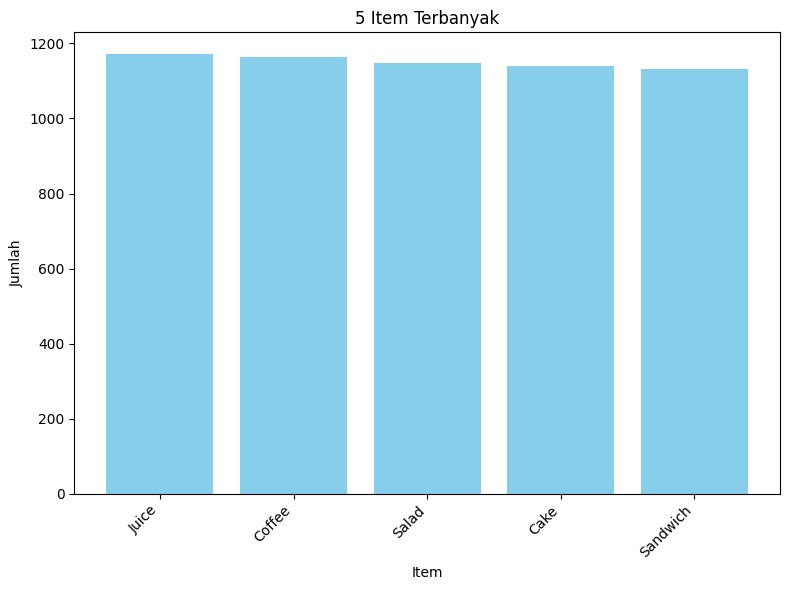

In [62]:
import matplotlib.pyplot as plt

VARIABEL = df['Item'].value_counts().head(5).sort_values(ascending=False) # head() jumlah yang mau ditampilkan & Urutan

plt.figure(figsize=(8,6)) # Ukuran
plt.bar(VARIABEL.index, VARIABEL.values, color='skyblue') # color warna
plt.xlabel('Item') # keterangan X label
plt.ylabel('Jumlah') # keterangan y label
plt.title('5 Item Terbanyak') # Judul
plt.xticks(rotation=45, ha='right') # rotasi teks
plt.tight_layout()
plt.show()

**Insight:**

Dari grafik 5 Item Terbanyak, terlihat bahwa:

*  Juice adalah item paling banyak terjual (1170), diikuti Coffee (1155), Salad
(1145), Cake (1135), dan Sandwich (1125)
*  Perbedaan jumlah penjualan antar 5 item sangat tipis/merata, selisihnya hanya sekitar 40-50 transaksi
*  Tidak ada item yang mendominasi secara signifikan semua item memiliki permintaan yang relatif seimbang

**Tindakan yang bisa diambil:**

Karena penjualan merata:

*  Pastikan stok semua item selalu tersedia, karena semuanya diminati hampir sama
*  Tidak perlu fokus hanya pada satu item semua item layak dipromosikan

Untuk meningkatkan penjualan:

*  Buat bundling promo misalnya Juice + Sandwich, atau Coffee + Cake
*  Cek apakah item tertentu lebih laku di waktu atau lokasi tertentu (analisis lanjutan dengan kolom Transaction Date dan Location)

Untuk analisis lebih lanjut:

*  Bandingkan Total Spent per Item untuk tahu item mana yang paling menguntungkan, bukan hanya yang paling banyak terjual


# **Pie Chart**

Pie Chart Matplotlib

In [65]:
df = df[~df['Payment Method'].isin(['UNKNOWN', 'ERROR'])]

df['Payment Method'].value_counts()

,count
Payment Method,
Digital Wallet,2291
Credit Card,2273
Cash,2258


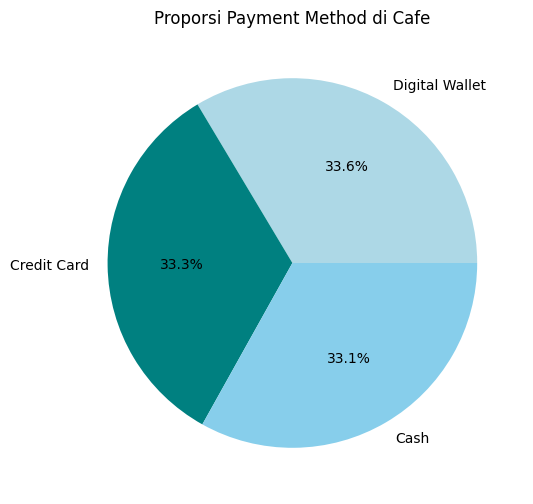

In [66]:
plt.figure(figsize=(8, 6))
plt.pie(df['Payment Method'].value_counts(), labels=df['Payment Method'].value_counts().index,
        autopct='%1.1f%%', colors=['lightblue', 'teal', 'skyblue'])
plt.title('Proporsi Payment Method di Cafe')
plt.show()

**Insight:**

*  Digital Wallet (33.6%), Credit Card (33.3%), Cash (33.1%) ketiganya sangat merata, hampir tidak ada perbedaan
*  Tidak ada lagi data kotor pie chart sekarang 100% valid
*  Pelanggan cafe ini tidak terikat pada satu metode pembayaran tertentu

**Tindakan Bisnis:**

*  Pastikan ketiga metode pembayaran selalu tersedia dan tidak ada gangguan sistem
*  Digital Wallet sedikit unggul bisa buat promo khusus seperti cashback atau poin reward
*  Credit Card tinggi pertimbangkan kerja sama dengan bank untuk cicilan 0%
*  Cash masih cukup besar (33.1%) jangan abaikan pelanggan yang tidak pakai digital payment

# **Line Chart**

Line Chart Matplotlib

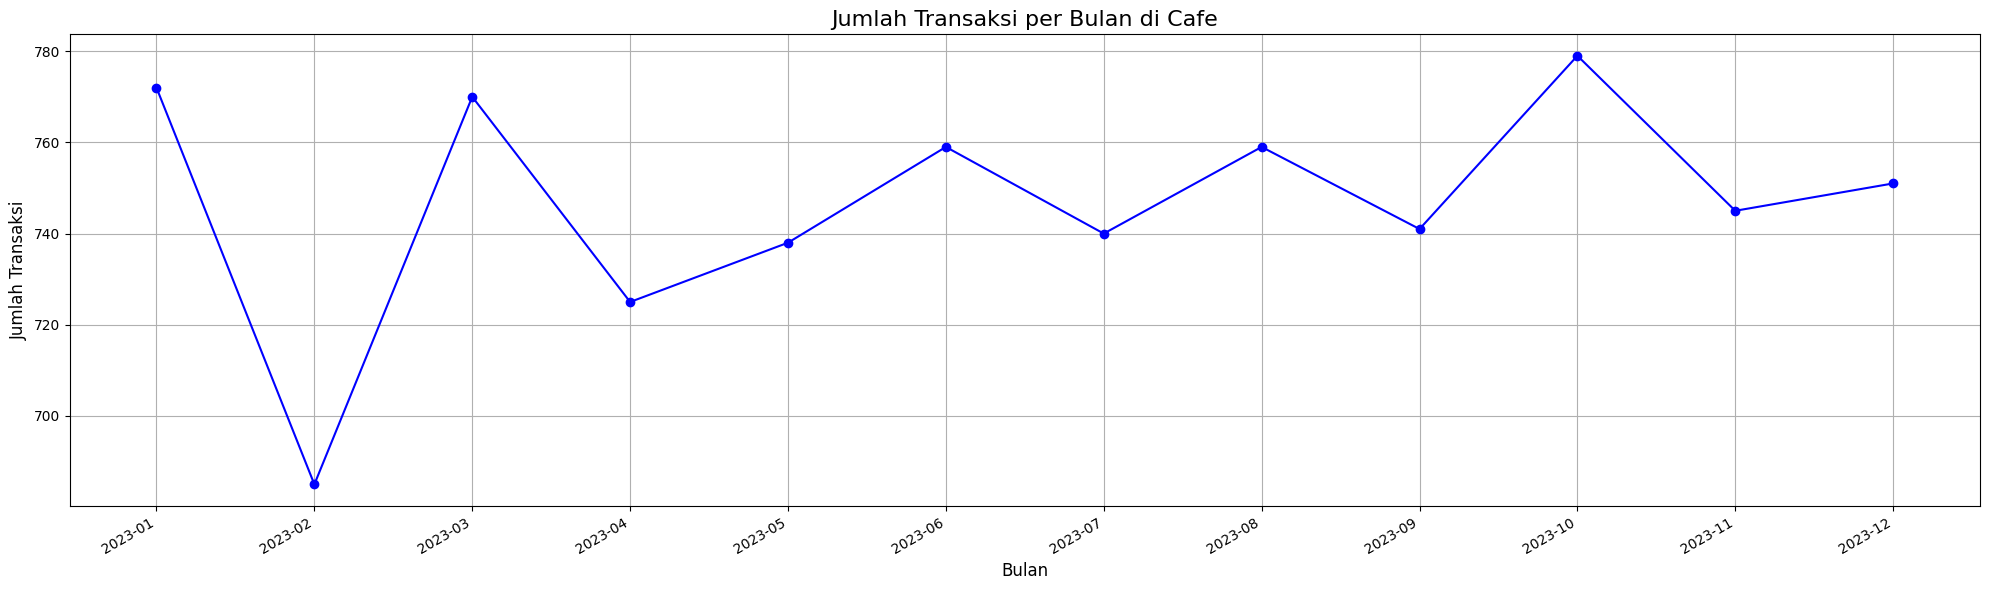

In [70]:
VARIABEL1 = df.groupby(df['Transaction Date'].dt.to_period('M')).size()

plt.figure(figsize=(20, 6))
plt.plot(VARIABEL1.index.astype(str), VARIABEL1.values, marker='o', color='blue')
plt.title('Jumlah Transaksi per Bulan di Cafe', fontsize=16)
plt.xlabel('Bulan', fontsize=12)
plt.ylabel('Jumlah Transaksi', fontsize=12)
plt.grid(True)
plt.gcf().autofmt_xdate()
plt.tight_layout()
plt.show()

**Insight:**
Dari line chart Jumlah Transaksi per Bulan di Cafe tahun 2023:

*  Februari 2023 adalah bulan terendah (688 transaksi) penurunan drastis dari Januari
*  Oktober 2023 adalah bulan tertinggi (779 transaksi) puncak transaksi sepanjang tahun
*  Setelah drop di Februari, terjadi pemulihan cepat di Maret (770)
*  Pola transaksi cenderung naik turun sepanjang tahun, tidak stabil.

**Tindakan Bisnis:**

*  Februari rendah investigasi penyebabnya (libur panjang, cuaca, promo kurang?), buat strategi khusus untuk bulan ini seperti promo Valentine
*  Oktober tinggi identifikasi apa yang berhasil di bulan ini dan replikasi strateginya di bulan lain
*  Fluktuasi tinggi buat program loyalitas atau langganan bulanan untuk menstabilkan jumlah transaksi
*  Lakukan analisis lebih dalam per bulan untuk tahu item apa yang paling laku di bulan puncak dan bulan sepi.

# **Histogram**

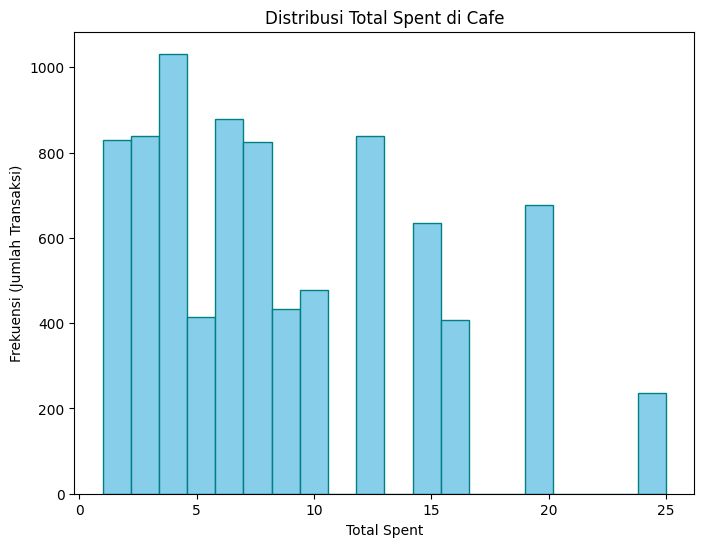

In [72]:
plt.figure(figsize=(8, 6))
plt.hist(df['Total Spent'], bins=20, color='skyblue', edgecolor='teal')
plt.title('Distribusi Total Spent di Cafe')
plt.xlabel('Total Spent')
plt.ylabel('Frekuensi (Jumlah Transaksi)')
plt.show()

**Insight:**

Dari histogram Distribusi Total Spent di Cafe:

*  Transaksi terbanyak berada di rentang 4–5 mayoritas pelanggan belanja nominal kecil
*  Rentang 1–8 mendominasi artinya sebagian besar pelanggan adalah pembeli kecil hingga menengah
*  Total Spent 12 memiliki lonjakan kedua, ada kelompok pelanggan yang belanja lebih besar
*  Total Spent di atas 20 sangat sedikit pelanggan yang belanja besar jumlahnya minoritas
*  Distribusi bersifat tidak normal ada beberapa puncak yang menunjukkan segmen pelanggan berbeda

**Tindakan Bisnis:**

*  Segmentasi pelanggan pisahkan pelanggan menjadi 3 kelompok: low spender (1–8), mid spender (8–15), high spender (15+)
*  Dorong low spender naik buat promo "tambah sedikit, dapat lebih" seperti bundling atau upgrade menu
*  Pertahankan high spender buat program VIP atau loyalty rewards khusus pelanggan dengan Total Spent tinggi
*  Buat paket menu di kisaran harga 10–12 untuk mendorong pelanggan belanja di rentang menengah.

# **Box Plot**

Box Plot Matplotlib

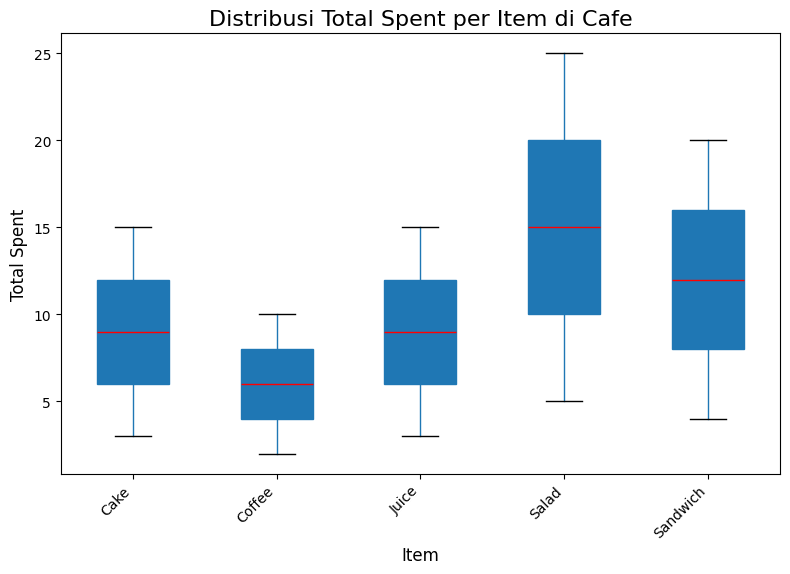

In [74]:
VARIABEL1 = df['Item'].value_counts().head(5).index
VARIABEL2 = df[df['Item'].isin(VARIABEL1)]

plt.figure(figsize=(8, 6))
VARIABEL2.boxplot(column='Total Spent', by='Item', ax=plt.gca(), grid=False, patch_artist=True, medianprops=dict(color='red'))
plt.title('Distribusi Total Spent per Item di Cafe', fontsize=16)
plt.xlabel('Item', fontsize=12)
plt.ylabel('Total Spent', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.suptitle('')
plt.tight_layout()
plt.show()

**Insight:**

Dari boxplot Distribusi Total Spent per Item di Cafe:

*  Salad memiliki median tertinggi dan range terluas, item paling mahal dan paling bervariasi harganya
*  Coffee memiliki median terendah dan range tersempit, item paling murah dan konsisten harganya
*  Cake & Juice memiliki median serupa, keduanya berada di segmen harga menengah
*  Sandwich median dengan range cukup lebar harga bervariasi, bisa masuk segmen menengah ke atas
*  Salad & Sandwich memiliki variasi harga paling tinggi kemungkinan ada variasi porsi atau topping.

Tindakan Bisnis:

*  Coffee harga rendah tapi transaksi banyak cocok dijadikan produk andalan / loss leader untuk menarik pelanggan
*  Salad harga tinggi pastikan kualitas terjaga dan bisa dijadikan menu premium dengan margin besar
*  Cake & Juice di harga menengah cocok untuk bundling promo bersama Coffee
*  Sandwich variasi harga lebar pertimbangkan membuat pilihan ukuran (small/large) agar lebih terstruktur.

# **Box Plot**

Box Plot Seaborn

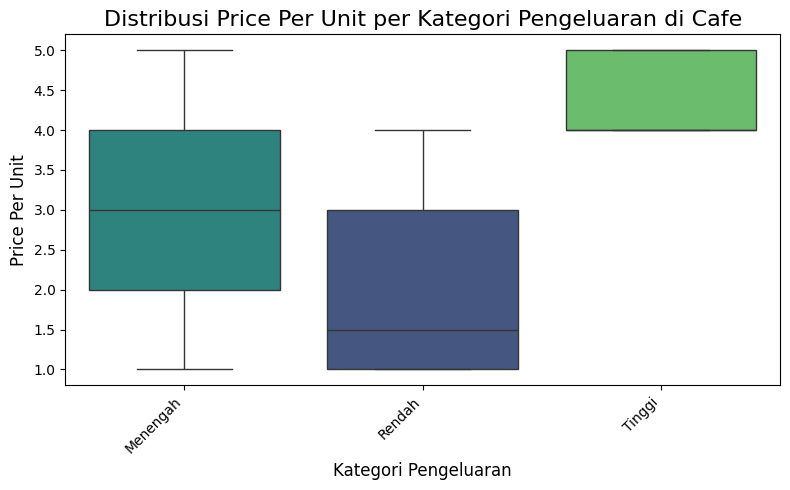

In [78]:
df = df[~df['Price Per Unit'].isin(['ERROR', 'UNKNOWN'])]
df['Price Per Unit'] = pd.to_numeric(df['Price Per Unit'], errors='coerce')
df = df.dropna(subset=['Price Per Unit'])

VARIABEL1 = df['kategori_pengeluaran'].value_counts().head(5).index
VARIABEL2 = df[df['kategori_pengeluaran'].isin(VARIABEL1)]

plt.figure(figsize=(8, 5))
sns.boxplot(x='kategori_pengeluaran', y='Price Per Unit', data=VARIABEL2, palette='viridis', order=VARIABEL1, hue='kategori_pengeluaran', legend=False)
plt.title('Distribusi Price Per Unit per Kategori Pengeluaran di Cafe', fontsize=16)
plt.xlabel('Kategori Pengeluaran', fontsize=12)
plt.ylabel('Price Per Unit', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

**Insight:**

Dari boxplot Distribusi Price Per Unit per Kategori Pengeluaran:

*  Tinggi memiliki Price Per Unit paling tinggi (4–5) dengan range sempit harga konsisten dan mahal
*  Menengah berada di kisaran 2–4, median 3 harga cukup bervariasi
*  Rendah memiliki Price Per Unit paling rendah (1–4), median 1.5 harga murah tapi variasinya cukup lebar
*  Kategori sudah sesuai logika, Tinggi > Menengah > Rendah

# **Tindakan Bisnis:**

*  Kategori Tinggi harga konsisten cocok dijadikan menu premium dengan pelayanan eksklusif
*  Kategori Menengah variasi lebar pertimbangkan standarisasi harga agar lebih konsisten
*  Kategori Rendah median rendah jadikan menu entry-level untuk menarik pelanggan baru
*  Buat strategi upselling dari Rendah → Menengah → Tinggi dengan bundling atau rekomendasi menu

# **Scatter Plot**

Scatter Plot Seaborn

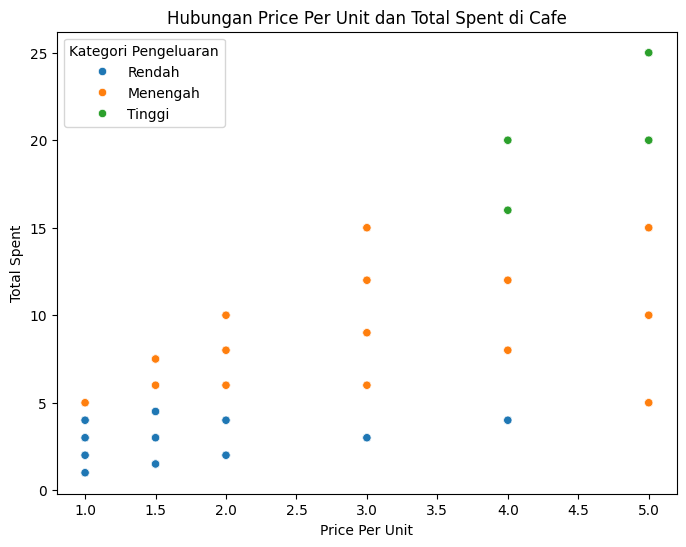

In [79]:
plt.figure(figsize=(8, 6))
sns.scatterplot(x='Price Per Unit', y='Total Spent', hue='kategori_pengeluaran', data=df)
plt.title('Hubungan Price Per Unit dan Total Spent di Cafe')
plt.xlabel('Price Per Unit')
plt.ylabel('Total Spent')
plt.legend(title='Kategori Pengeluaran')
plt.show()

**Insight:**

Dari scatter plot Hubungan Price Per Unit dan Total Spent di Cafe:

*  Tren positif jelas semakin tinggi Price Per Unit, semakin tinggi Total Spent
*  Kategori Tinggi (hijau) hanya muncul di Price Per Unit 4–5 dengan Total Spent 16–25 konsisten sebagai segmen premium
*  Kategori Menengah (orange) tersebar merata di semua harga paling bervariasi dan paling banyak titiknya
*  Kategori Rendah (biru) dominan di Price Per Unit 1–2 dengan Total Spent rendah (1–5) segmen ekonomis
Titik-titik membentuk pola kolom vertikal di harga 1, 1.5, 2, 3, 4, 5 artinya harga di cafe ini sudah terstandarisasi

Tindakan Bisnis:

*  Segmentasi sudah terbentuk alami Rendah, Menengah, Tinggi sudah jelas terpisah
*  Menengah paling potensial jumlah transaksi terbanyak, bisa didorong ke segmen Tinggi dengan upselling
*  Tinggi/premium hanya di harga 4–5 pertimbangkan tambah menu premium baru di harga 6–7

# **Bubble Chart**

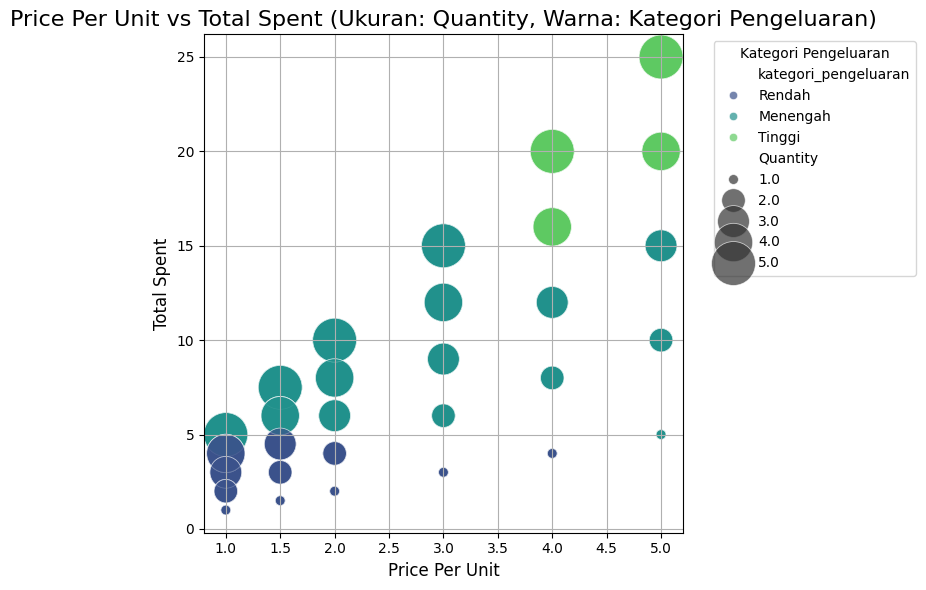

In [80]:
plt.figure(figsize=(8, 6))
sns.scatterplot(x='Price Per Unit', y='Total Spent', size='Quantity', hue='kategori_pengeluaran', data=df, sizes=(50, 1000), alpha=0.7, palette='viridis')
plt.title('Price Per Unit vs Total Spent (Ukuran: Quantity, Warna: Kategori Pengeluaran)', fontsize=16)
plt.xlabel('Price Per Unit', fontsize=12)
plt.ylabel('Total Spent', fontsize=12)
plt.grid(True)
plt.legend(title='Kategori Pengeluaran', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

**Insight:**

Dari scatter plot Price Per Unit vs Total Spent:

*  Tren positif kuat semakin tinggi Price Per Unit, semakin besar Total Spent dan semakin besar ukuran titik (Quantity)
*  Kategori Tinggi (hijau) dominan di Price Per Unit 4–5 dengan Total Spent 16–25 dan titik paling besar beli sedikit tapi mahal
*  Kategori Menengah (tosca) tersebar di semua harga, ukuran titik bervariasi segmen paling beragam
*  Kategori Rendah (biru tua) menumpuk di Price Per Unit 1–2, titik kecil beli murah dan sedikit
*  Quantity tinggi (titik besar) lebih banyak di harga rendah-menengah pelanggan murah cenderung beli lebih banyak unit

**Tindakan Bisnis:**

*  Kategori Tinggi fokus pada kualitas dan pengalaman, bukan kuantitas
*  Kategori Rendah beli banyak tapi murah tawarkan paket bundling agar Total Spent naik
*  Kategori Menengah paling potensial dorong dengan promo "beli 3 gratis 1" atau diskon quantity
*  Strategi volume vs margin: Rendah = volume tinggi, Tinggi = margin besar optimalkan keduanya

# **Heatmap**

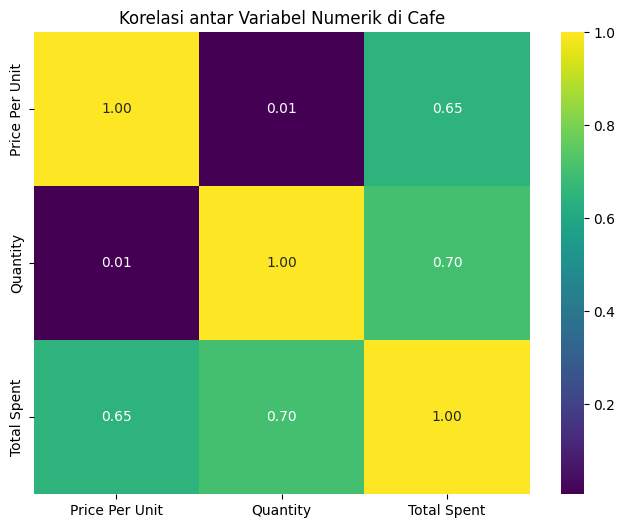

In [81]:
plt.figure(figsize=(8, 6))
sns.heatmap(data=df[['Price Per Unit', 'Quantity', 'Total Spent']].corr(),
            annot=True,
            cmap='viridis',
            fmt='.2f')
plt.title('Korelasi antar Variabel Numerik di Cafe')
plt.show()

**Insight:**

Dari heatmap Korelasi antar Variabel Numerik di Cafe:

*  Quantity, Total Spent: 0.70 korelasi kuat positif semakin banyak item dibeli, semakin besar total belanja
*  Price Per Unit, Total Spent: 0.65 korelasi cukup kuat harga per unit juga berpengaruh signifikan terhadap total belanja
*  Price Per Unit, Quantity: 0.01 korelasi hampir nol harga tidak mempengaruhi jumlah item yang dibeli, pelanggan beli sesuai kebutuhan bukan harga.

**Tindakan Bisnis:**

*  Dorong Quantity karena paling berpengaruh ke Total Spent, buat promo "beli lebih banyak, hemat lebih banyak"
*  Naikkan harga secara strategis Price Per Unit berpengaruh ke Total Spent, kenaikan harga tidak akan kurangi jumlah pembelian
*  Bundling produk gabungkan item murah + mahal untuk tingkatkan Quantity sekaligus Total Spent